--- valori lipsă in train ---

nume                  0
an_lansare            0
gen_principal         0
nr_platforme          0
timp_joc_mediu        0
rating_utilizatori    0
nr_recenzii           0
nr_realizari          0
este_hit              0
dtype: int64
--- statistici descriptive ---

        an_lansare  nr_platforme  timp_joc_mediu  rating_utilizatori  \
count   611.000000    611.000000      611.000000          611.000000   
mean   2013.119476      4.505728        7.039280            3.801064   
std       4.915395      2.153430        9.718249            0.467643   
min    1994.000000      1.000000        0.000000            2.230000   
25%    2011.000000      3.000000        3.000000            3.530000   
50%    2014.000000      4.000000        5.000000            3.870000   
75%    2017.000000      6.000000        8.000000            4.140000   
max    2023.000000     13.000000      121.000000            4.640000   

       nr_recenzii  nr_realizari    este_hit  
count   611.

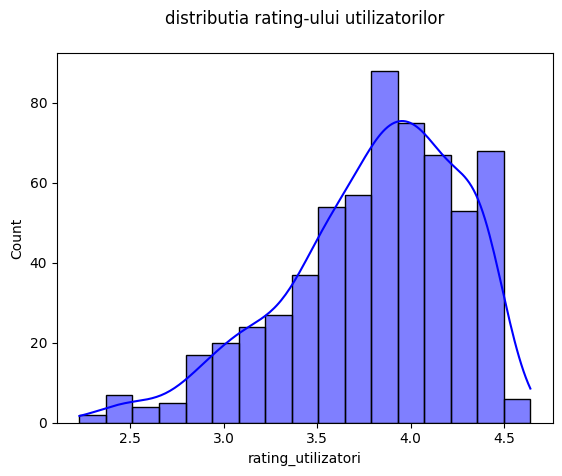

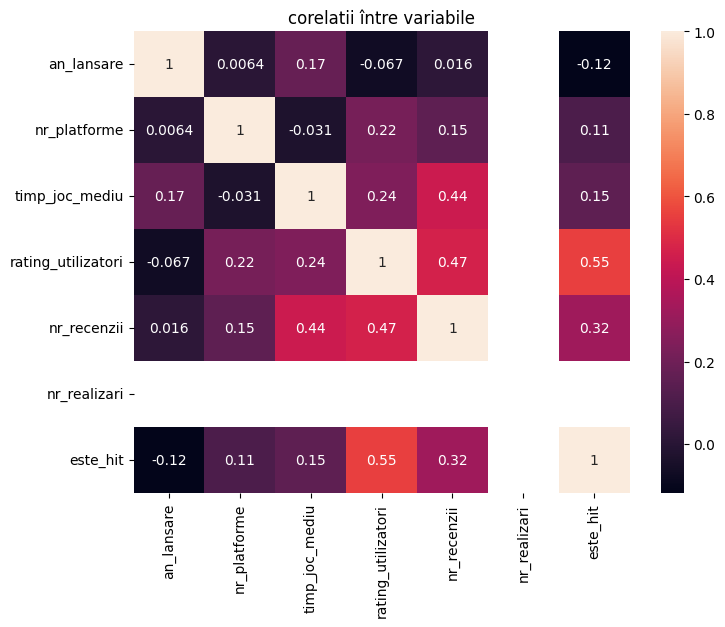

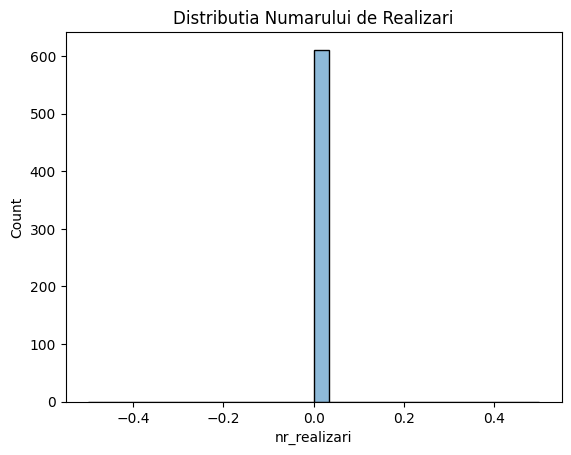

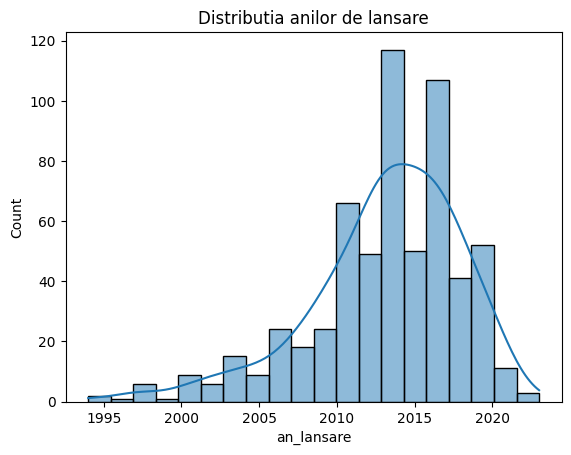

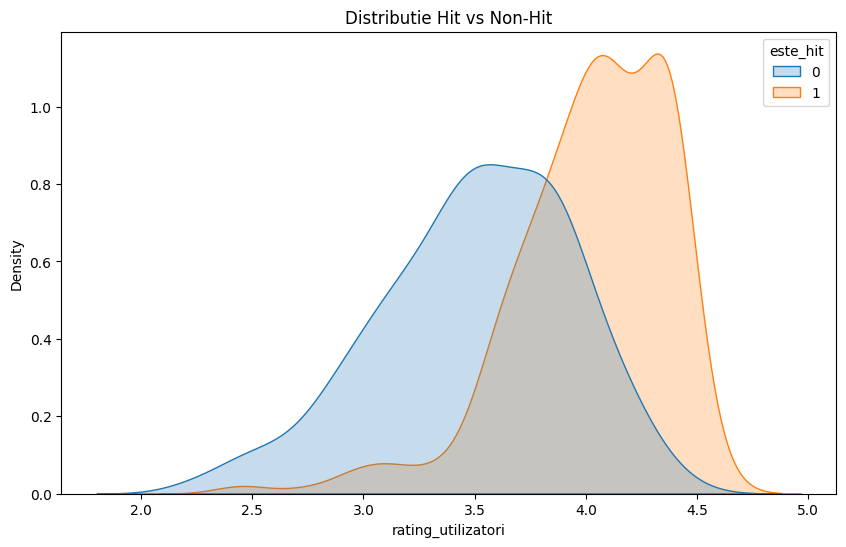

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#punem datele din fisierele de train si test
df_train = pd.read_csv("train_dataset.csv")
df_test = pd.read_csv("test_dataset.csv")

#afisam primele 5 randuri pentru verificare
df_train.head()

#vedem daca avem date lipsa pt cleaning
print("--- valori lipsă in train ---\n")
print(df_train.isnull().sum())

#statistici descriptive
print("--- statistici descriptive ---\n")
print(df_train.describe())

#schimba rating cu numele coloanei daca e in api are alt nume
sns.histplot(df_train['rating_utilizatori'], kde=True, color='blue')
plt.title('distributia rating-ului utilizatorilor\n')
plt.show()

#facem un heatmap pentru corelatii
plt.figure(figsize=(8, 6))
sns.heatmap(df_train.corr(numeric_only=True), annot=True)
plt.title('corelatii între variabile')
plt.show()

#distributia jocurilor dupa nr de
sns.histplot(df_train['nr_realizari'], bins=30, kde=True)
plt.title('Distributia Numarului de Realizari')
plt.show()

#histograma pentru cum sunt impartite datele pe ani
sns.histplot(df_train['an_lansare'], bins=20, kde=True)
plt.title('Distributia anilor de lansare')
plt.show()

#facem un hue pentru a separa cei care considera jocul un hit sau nu
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_train, x='rating_utilizatori', hue='este_hit', fill=True, common_norm=False)
plt.title('Distributie Hit vs Non-Hit')
plt.show()

#facem data cleaning pentru antrenare
df_train = df_train.drop(columns=['nr_realizari'])
df_test = df_test.drop(columns=['nr_realizari'])

print("Coloana nr_realizari a fost eliminata cu succes.")